# NB01 Text Representation (Axis1)

## Member1 (Rui): TF-IDF Unigrams & Bigrams (Week01)
 Input: nlp_abstracts_cleaned.csv

 Output: tfidf_unigram_matrix.pkl, tfidf_bigram_matrix.pkl

**Note**: 
The current version (Week01) is a sample based on **10% of the data**. It aims to quickly generate a sample matrix to resolve the potential problems for Member 3, 4, and 5. 
 Full data operation will be conducted in Week 03.

In [1]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
df_nlp = pd.read_csv("../data/nlp_abstracts_cleaned.csv")

In [3]:
print(f"TOTAL: {len(df_nlp)}")
print(df_nlp["period"].value_counts().sort_index())

TOTAL: 32221
period
1991-1995      448
1996-2000      659
2001-2005      279
2006-2010      364
2011-2015     2066
2016-2021    28405
Name: count, dtype: int64


### Sample 10%

In [4]:
# sample 10% of the data
df = df_nlp.sample(frac=0.1, random_state=42).copy()
print(f"TOTAL: {len(df_nlp)}")
print(f"SAMPLE 10%: {len(df)}") 

TOTAL: 32221
SAMPLE 10%: 3222


In [5]:
# text cleaning
def clean_abstract(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)   
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [6]:
df["abstract_clean"] = df["abstract"].apply(clean_abstract)
df = df[df["abstract_clean"].str.len() > 20].copy()
print(f"the Number of 10% Papers after Cleaning: {len(df)}")

the Number of 10% Papers after Cleaning: 3222


### Fitting TF-IDF on 10% sample

In [7]:
# sublinear_tf=True  --- use log to take word frequency, compress the weight of high-frequency words
# min_df=2 --- at least appears in 2 papers
# max_df=0.85 ---remove words that appear in more than 85% of the papers
# max_features = 10000 --- prevent filtering too many useful words on 10% of the samples

vectorizer_uni = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.85,
    max_features=10000,
    stop_words="english",
    sublinear_tf=True,
)

vectorizer_bi = TfidfVectorizer(
    ngram_range=(2, 2),
    min_df=2,
    max_df=0.85,
    max_features=10000,
    stop_words="english",
    sublinear_tf=True,
)

In [8]:
uni_matrix = vectorizer_uni.fit_transform(df["abstract_clean"])
bi_matrix = vectorizer_bi.fit_transform(df["abstract_clean"])

print(f"the shape of Unigram: {uni_matrix.shape}")
print(f"the shape of Bigram: {bi_matrix.shape}")

the shape of Unigram: (3222, 7993)
the shape of Bigram: (3222, 10000)


In [9]:
# Save for later use
with open("../outputs/tfidf_unigram_matrix.pkl", "wb") as f:
    pickle.dump({
        "matrix":     uni_matrix,
        "vectorizer": vectorizer_uni,
        "index":      df.index,
        "period":     df["period"].values,
        "era":        df["era"].values,
    }, f)

with open("../outputs/tfidf_bigram_matrix.pkl", "wb") as f:
    pickle.dump({
        "matrix":     bi_matrix,
        "vectorizer": vectorizer_bi,
        "index":      df.index,
        "period":     df["period"].values,
        "era":        df["era"].values,
    }, f)

### TOP N keywords on 10% sample

In [10]:
# Top-N by period
def top_terms_per_period(matrix, vectorizer, df, period_col="period", top_n=20):
    """
    dict: {period: [(term, score), ...]}
    method: Sum the TF-IDF scores of all papers in each period and take the top_n.
    """
    feat = vectorizer.get_feature_names_out()
    periods = sorted(df[period_col].unique())
    results = {}
    for period in periods:
        mask = (df[period_col] == period).values
        # summed = np.asarray(matrix[mask].sum(axis=0)).flatten()
        summed = np.asarray(matrix[mask].mean(axis=0)).flatten()
        top_idx = summed.argsort()[::-1][:top_n]
        results[period] = [(feat[i], round(summed[i], 2)) for i in top_idx]
    return results


print("\nUnigram Top 20 per period ")
uni_top = top_terms_per_period(uni_matrix, vectorizer_uni, df, top_n=20)
for period, terms in uni_top.items():
    print(f"{period}: {', '.join(t[0] for t in terms)}")

print("\nBigram Top 20 per period ")
bi_top = top_terms_per_period(bi_matrix, vectorizer_bi, df, top_n=20)
for period, terms in bi_top.items():
    print(f"{period}: {', '.join(t[0] for t in terms)}")



Unigram Top 20 per period 
1991-1995: grammars, grammar, ambiguity, lexical, theory, based, parsing, language, algorithm, presents, used, paper, corpus, present, formalism, disambiguation, implemented, linguistic, results, model
1996-2000: algorithm, paper, words, constraints, speech, based, language, dialogue, word, set, use, problem, information, method, grammars, used, linguistic, pronouns, grammar, described
2001-2005: language, algorithm, proposed, parsing, used, paper, annotation, corpus, corpora, application, analysis, natural, likelihood, algorithms, maximum, programming, present, automata, using, applications
2006-2010: automata, words, rules, resources, paper, introduced, used, documents, lexicon, language, annotation, written, parallel, logical, case, algorithm, russian, based, tool, linguistic
2011-2015: language, based, words, paper, word, approach, using, text, used, translation, model, results, information, features, different, languages, learning, use, models, data
201

### Vocabulary Comparison on 10% sample

In [11]:
# Vocabulary Comparison Across Periods (Rise VS. Disappearance)
def vocab_shift(top_terms_dict, early_periods, late_periods):
    early_words = set()
    late_words  = set()
    for p in early_periods:
        if p in top_terms_dict:
            early_words.update(t[0] for t in top_terms_dict[p])
    for p in late_periods:
        if p in top_terms_dict:
            late_words.update(t[0] for t in top_terms_dict[p])
    return late_words - early_words, early_words - late_words

early = ["1991-1995", "1996-2000", "2001-2005"]
late  = ["2011-2015", "2016-2021"]

uni_emerged, uni_disappeared = vocab_shift(uni_top, early, late)
print(f"\nUnigram emerging words: {sorted(uni_emerged)}")
print(f"Unigram disappearing words: {sorted(uni_disappeared)}")

bi_emerged, bi_disappeared = vocab_shift(bi_top, early, late)
print(f"\nBigram emerging words: {sorted(bi_emerged)}")
print(f"Bigram disappearing words: {sorted(bi_disappeared)}")




Unigram emerging words: ['approach', 'data', 'different', 'features', 'languages', 'learning', 'models', 'neural', 'performance', 'propose', 'state', 'task', 'tasks', 'text', 'training', 'translation']
Unigram disappearing words: ['algorithm', 'algorithms', 'ambiguity', 'analysis', 'annotation', 'application', 'applications', 'automata', 'constraints', 'corpora', 'corpus', 'described', 'dialogue', 'disambiguation', 'formalism', 'grammar', 'grammars', 'implemented', 'lexical', 'likelihood', 'linguistic', 'maximum', 'method', 'natural', 'parsing', 'present', 'presents', 'problem', 'programming', 'pronouns', 'proposed', 'set', 'speech', 'theory']

Bigram emerging words: ['arabic language', 'based approach', 'deep learning', 'end end', 'et al', 'experimental results', 'information retrieval', 'language model', 'language models', 'large scale', 'literary texts', 'low dimensional', 'machine translation', 'neural network', 'neural networks', 'paper propose', 'pre trained', 'propose novel', '

### Representative vocabulary changes by period (10% sample)

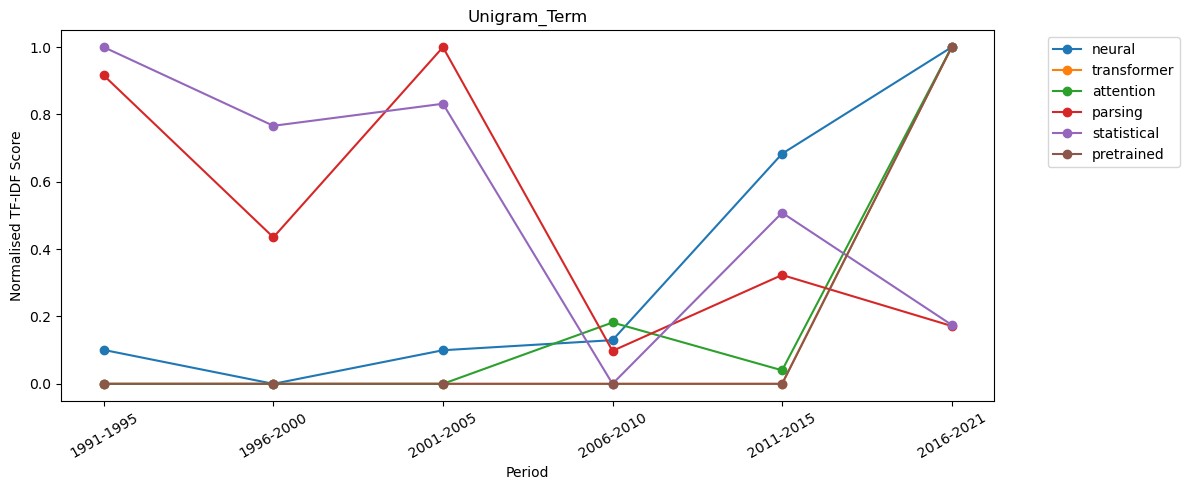

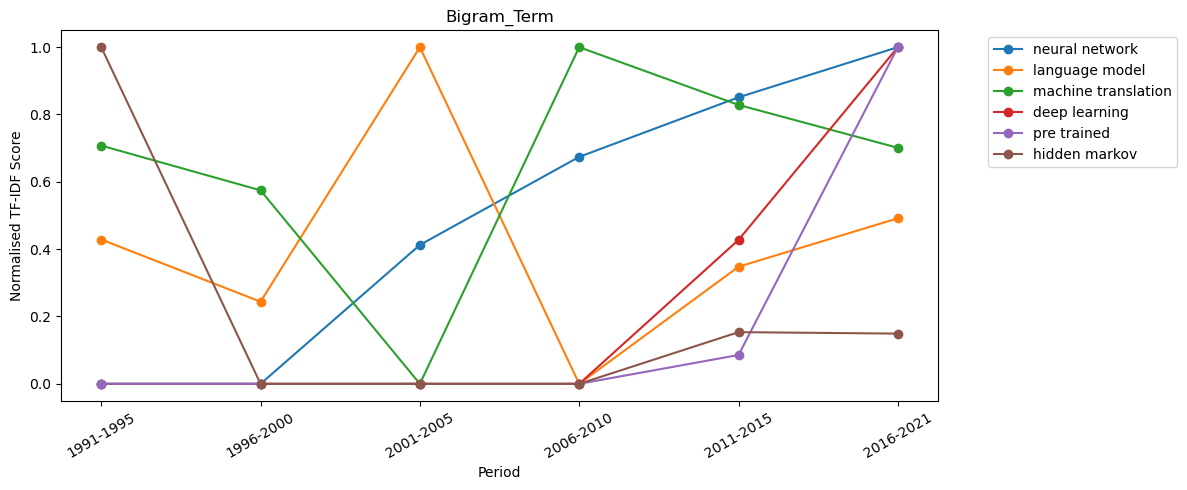

In [12]:
def plot_term_trends(matrix, vectorizer, df, terms, period_col="period", title=""):
    feat  = list(vectorizer.get_feature_names_out())
    periods = sorted(df[period_col].unique())
    valid = [t for t in terms if t in feat]
    if not valid:
        print("None specified terms")
        return

    scores = {t: [] for t in valid}
    for period in periods:
        mask = (df[period_col] == period).values
        # summed = np.asarray(matrix[mask].sum(axis=0)).flatten()
        summed = np.asarray(matrix[mask].mean(axis=0)).flatten()
        for t in valid:
            scores[t].append(summed[feat.index(t)])

    fig, ax = plt.subplots(figsize=(12, 5))
    for t, vals in scores.items():
        v = np.array(vals)
        if v.max() > 0:
            v = v / v.max()
        ax.plot(periods, v, marker="o", label=t)

    ax.set_title(title)
    ax.set_xlabel("Period")
    ax.set_ylabel("Normalised TF-IDF Score")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(f"../figures/{title.replace(' ', '_')}.png", dpi=150)
    plt.show()

unigram_track = ["neural", "transformer", "attention", "parsing", "statistical", "pretrained"]
plot_term_trends(uni_matrix, vectorizer_uni, df, unigram_track, title="Unigram_Term")

bigram_track = ["neural network", "language model", "machine translation",
                "deep learning", "pre trained", "hidden markov"]
plot_term_trends(bi_matrix, vectorizer_bi, df, bigram_track, title="Bigram_Term")



According to Unigram plot: 

 - "Statistical" was the absolute king in 1991-1995, then declined; parsing (syntactic analysis, a core task of early NLP) peaked in 2001-2005 and then began to decline. 
 - "Neural", "Attention", "Transformer" (the terms of the deep learning era) were all zeros until 2010, and then exploded after 2015

According to Bigram plot: 
 - "hidden markov" (the early leader in speech and sequence annotation) was at its peak in the 1990s and has since gradually been phased out. 
 - "Machine translation" had a clear peak around 2006-2010, when statistical machine translation SMT was at its best
 - "Neural network" and "Deep learning" have been leading in the last decade.

# Member 2 (XXX): XXXXX